## Indonesia Emas 2045

### Chebysev dengan Fungsi yang dikeathui

In [1]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import Chebyshev

In [2]:
# Define the function to be approximated
def f(x):
    #return np.exp(x / 10)
    return np.sin(x) * np.exp(x / 10) 
    #return 10*np.sin(x-10)/(x-10)

# Define the interval
a, b = 0, 30

# Map interval to [-1, 1]
def map_to_chebyshev (x):
    return (2 * x - (b + a)) / (b - a)


In [3]:

# Number of Chebyshev nodes
n = 100

# Chebyshev nodes
x_k = np.cos((2 * np.arange(n + 1) + 1) * np.pi / (2 * (n + 1)))

# Map nodes back to original interval
x_k_mapped = 0.5 * (a + b) + 0.5 * (b - a) * x_k

# Evaluate function at the nodes
y_k = f(x_k_mapped)

# Fit Chebyshev polynomial
chebyshev_poly = Chebyshev.fit(x_k_mapped, y_k, n)
#print(chebyshev_poly)

# Evaluate the polynomial
x_vals = np.linspace(a, b, 100)
y_approx = chebyshev_poly(x_vals)

x_ori = np.linspace(a, 100, 100)

# Extrapolate beyond the interval [-10, 10]
x_extrap = np.linspace(10, 15, 10)
y_extrap = chebyshev_poly(x_extrap)


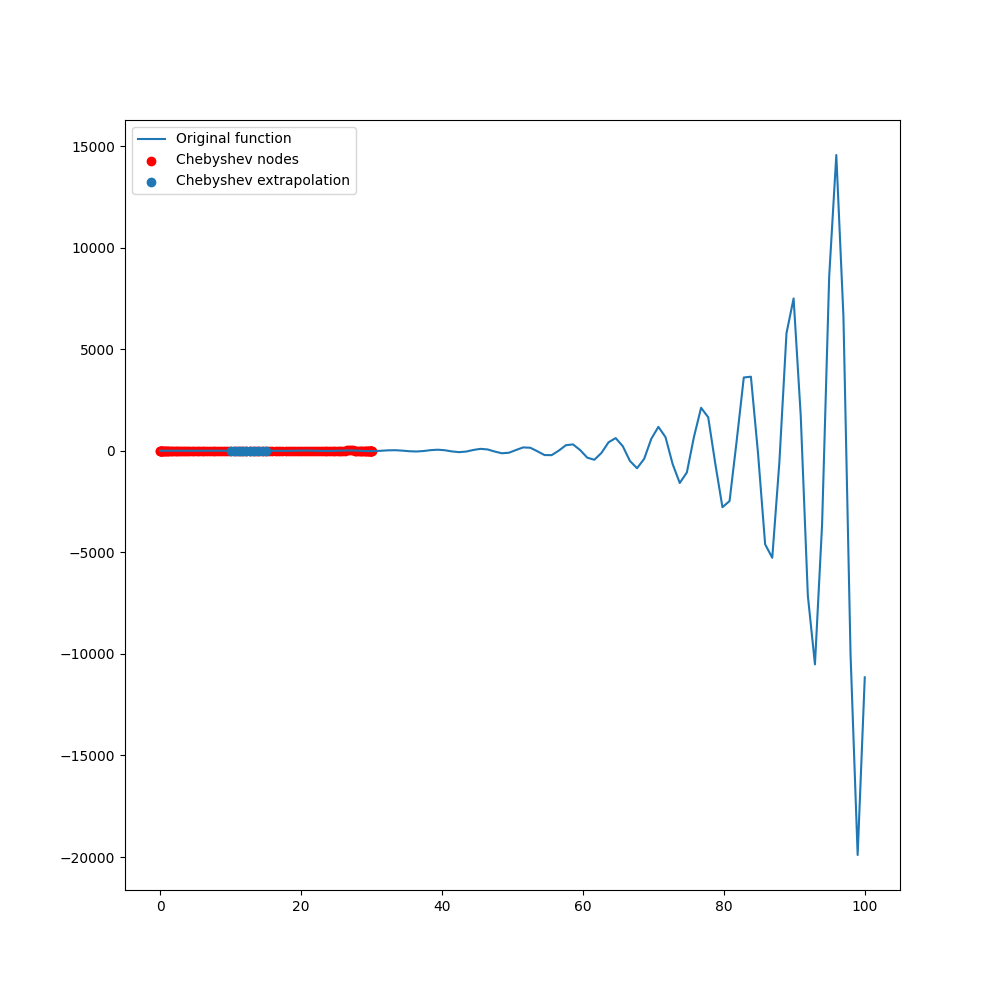

In [4]:
fig, ax = plt.subplots (figsize = (10, 10))

# Plot the function and its approximation
ax.plot(x_ori, f(x_ori), label='Original function')
#ax.plot(x_vals, y_approx, label='Chebyshev approximation')
ax.scatter(x_k_mapped, y_k, color='red', label='Chebyshev nodes')

# Plot the extrapolation
ax.scatter(x_extrap, y_extrap, label='Chebyshev extrapolation')
ax.legend()
plt.show()

### Chebyshev dengan Titik titik yang diketahui

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from numpy.polynomial.chebyshev import Chebyshev
import random

In [6]:
# Data titik-titik yang diketahui

x_known =  np.arange (0, 100, 1)
y_known = np.array(range (len (x_known)), float)

for i in range (len (x_known)):
    y_known[i] = random.uniform (-3.0, 3.0)
print(len(x_known))

100


In [7]:
# Interval dari titik-titik yang diketahui
a, b = x_known[0], x_known[-1]

# Menentukan Node Chebyshev
n = 120

x_k = np.cos((2 * np.arange(n + 1) + 1) * np.pi / (2 * (n + 1)))

# Memetakan Node Chebyshev ke interval yang diketahui
x_k_mapped = 0.5 * (a + b) + 0.5 * (b - a) * x_k
cs=CubicSpline(x_known, y_known)
y_k_mapped = cs(x_k_mapped)

# Menyesuaikan polinomial Chebyshev dengan titik-titik yang diketahui
chebyshev_poly = Chebyshev.fit (x_k_mapped, y_k_mapped , n)

In [8]:
for i in range (len (x_k_mapped)):
    print (f"\tx[{i}] = {x_k_mapped[i]} | y[{i}] = {y_k_mapped[i]}\n")

	x[0] = 98.99582901990294 | y[0] = 2.0305074284828164

	x[1] = 98.9624653964807 | y[1] = 2.0581021100655885

	x[2] = 98.89576063903358 | y[2] = 2.0769827218856167

	x[3] = 98.79575971119698 | y[3] = 2.0213857987571515

	x[4] = 98.6625300205356 | y[4] = 1.8097373847391094

	x[5] = 98.49616137310616 | y[5] = 1.364960188198913

	x[6] = 98.29676591292184 | y[6] = 0.6412539111788127

	x[7] = 98.06447804635945 | y[7] = -0.3429021695259353

	x[8] = 97.7994543515602 | y[8] = -1.465834684994192

	x[9] = 97.50187347288517 | y[9] = -2.4582172351669453

	x[10] = 97.1719360004966 | y[10] = -2.853489141159315

	x[11] = 96.80986433514622 | y[11] = -1.9725154559412719

	x[12] = 96.41590253826172 | y[12] = 0.2017579845228149

	x[13] = 95.99031616743235 | y[13] = 2.5108941376491845

	x[14] = 95.5333920974048 | y[14] = 3.4889598307825826

	x[15] = 95.04543832670956 | y[15] = 2.7544214058212457

	x[16] = 94.52678377004867 | y[16] = 0.5506835704691352

	x[17] = 93.97777803658425 | y[17] = -1.37394187222003

In [9]:
# Mengevaluasi polinomial pada interval yang diketahui
x_vals = np.linspace (a, b, 1000)
y_approx = chebyshev_poly (x_vals)

# Melakukan ekstrapolasi di luar interval yang diketahui
x_extrap = np.linspace(b, b + 1, 10)
y_extrap = chebyshev_poly(x_extrap)

In [10]:
print (f"\t=== Data baru ===\n")
for i in range (len (x_extrap)):
    print (f"\tx[{i}] = {x_extrap[i]} | y[{i}] = {y_extrap[i]}\n")
print (f"\t=== original data  ===\n")
for i in range (len (x_known)):
    print (f"\tx[{i}] = {x_known[i]} | y[{i}] = {y_known[i]}\n")

	=== Data baru ===

	x[0] = 99.0 | y[0] = 1.8948562792454582

	x[1] = 99.11111111111111 | y[1] = -214.71669369859

	x[2] = 99.22222222222223 | y[2] = -6175.665371295108

	x[3] = 99.33333333333333 | y[3] = -80602.60080452857

	x[4] = 99.44444444444444 | y[4] = -701467.0538989753

	x[5] = 99.55555555555556 | y[5] = -4711793.607003707

	x[6] = 99.66666666666667 | y[6] = -26328815.299906015

	x[7] = 99.77777777777777 | y[7] = -127960725.36858666

	x[8] = 99.88888888888889 | y[8] = -556828749.7057185

	x[9] = 100.0 | y[9] = -2213701841.1295033

	=== original data  ===

	x[0] = 0 | y[0] = -2.871438283260524

	x[1] = 1 | y[1] = -0.18132641830755514

	x[2] = 2 | y[2] = -1.325335370147748

	x[3] = 3 | y[3] = -1.0668896633362575

	x[4] = 4 | y[4] = -1.0675770579785318

	x[5] = 5 | y[5] = 0.5506477536854062

	x[6] = 6 | y[6] = 2.977624453120968

	x[7] = 7 | y[7] = 2.4338047938249296

	x[8] = 8 | y[8] = -1.6943454265067048

	x[9] = 9 | y[9] = -0.7054932586945304

	x[10] = 10 | y[10] = -0.935430466

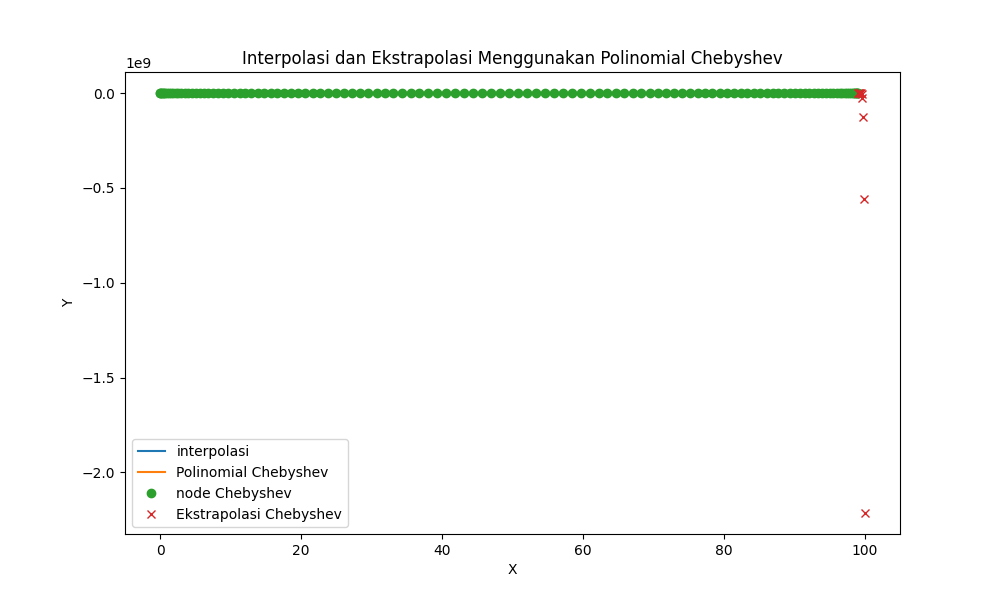

In [11]:
# Plot hasil
fig, ax1 = plt.subplots (figsize=(10, 6))
#ax1.plot (x_known, y_known, label='Titik-titik yang diketahui')
ax1.plot (x_known, cs(x_known), '-', label='interpolasi')
ax1.plot (x_vals, y_approx, '-', label='Polinomial Chebyshev')
ax1.plot (x_k_mapped,y_k_mapped, 'o', label='node Chebyshev')
ax1.plot (x_extrap, y_extrap, 'x', label='Ekstrapolasi Chebyshev')
ax1.legend ()
ax1.set_xlabel ('X')
ax1.set_ylabel ('Y')
ax1.set_title ('Interpolasi dan Ekstrapolasi Menggunakan Polinomial Chebyshev')
plt.show ()